In [1]:
import Pkg
Pkg.activate("/home/matteo/Projects/OU_inference/")

  Activating project at `~/Projects/OU_inference`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, LinearAlgebra, PyPlot

Precompiling DiffusionEvolution
  ✓ Zygote → ZygoteColorsExt
  ✓ Zygote → ZygoteDistancesExt
  ✓ Flux
  ✓ DiffusionEvolution
  4 dependencies successfully precompiled in 104 seconds. 175 already precompiled.
  2 dependencies had output during precompilation:
┌ Zygote → ZygoteColorsExt
│  ┌ Warning: attempting to remove probably stale pidfile
│  │   path = "/home/matteo/.julia/compiled/v1.10/Zygote/4kbLI_MxBOU.ji.pidfile"
│  └ @ FileWatching.Pidfile ~/Software/julia-1.10.5/share/julia/stdlib/v1.10/FileWatching/src/pidfile.jl:244
│  ┌ Warning: failed to remove pidfile on close
│  │   path = "/home/matteo/.julia/compiled/v1.10/Zygote/4kbLI_MxBOU.ji.pidfile"
│  │   removed = false
│  └ @ FileWatching.Pidfile ~/Software/julia-1.10.5/share/julia/stdlib/v1.10/FileWatching/src/pidfile.jl:342
└  
┌ Zygote → ZygoteDistancesExt
│  ┌ Warning: attempting to remove probably stale pidfile
│  │   path = "/home/matteo/.julia/compiled/v1.10/Zygote/4kbLI_MxBOU.ji.pidfile"
│  └ @ FileWatching.Pidfile ~/So

In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x,y,d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 50

50

In [63]:
β = 0.1

0.1

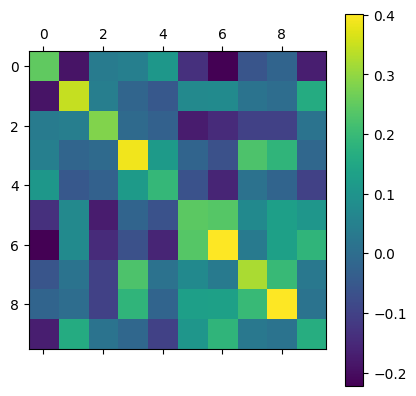

PyObject <matplotlib.colorbar.Colorbar object at 0x75218550b220>

In [64]:
m = randn(d,d)
J = (m * m') * (β/sqrt(d))
matshow(J)
colorbar()

In [65]:
θ = randn(d)
θ ./= norm(θ)
θ .*= 10*d

10-element Vector{Float64}:
 -22.627262558479885
   1.2532809422776574
 -44.16592741361886
  -7.5483335398706775
  -5.574289247389887
   2.705779619284925
  21.347459356771626
 -33.03695116052892
  23.863807724243145
  72.96437737979822

In [66]:
γ = 0.01

0.01

In [67]:
x_sim = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T, err_sym=1e-6);

Σ has been symmetrized


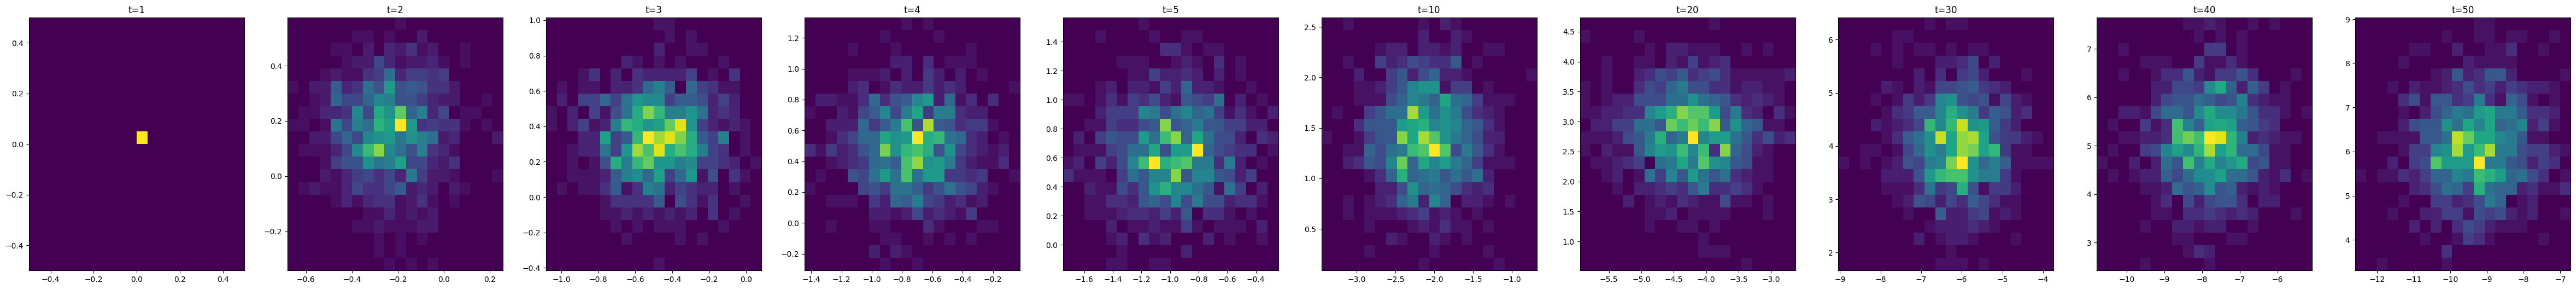

In [68]:
t_view = [1,2,3,4,5,10,20,30,40,50]
fig, ax =subplots(1, length(t_view), 6)
for i in eachindex(t_view)
    ax[i].hist2d(x_sim[1,:,t_view[i]], x_sim[2,:,t_view[i]], bins=20)
    ax[i].set_title("t=$(t_view[i])")
end

In [80]:
t_sample = [1,5,10]

3-element Vector{Int64}:
  1
  5
 10

# Single thread

In [81]:
data = collect_data(zeros(d), x_sim[:,:,t_sample], fill(1.0, nsamples, length(t_sample)), t_sample)

Data([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], DiffusionEvolution.Sample[DiffusionEvolution.Sample([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]), DiffusionEvolution.Sample([-0.9703843108654641 -0.968002026054904 … -1.2852899935617903 -0.9012963978995442; 0.8220051168319037 0.8987280451504511 … 0.6023748814010652 1.2744415147428028; … ; 0.20644854800482282 0.9498856956760433 … 0.7161941965458463 0.27398334527383983; 1.0500602721397039 0.7269751533879522 … 0.6232391586496763 0.9452997188702197], [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001  …  0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]), DiffusionEvolution.Sample([-1.953044611282035 -2.3355775775909313 … -2.421291626100364 -2.9831174281591584; 2.2256197125251553 1.9929966146833429 … 0.96951079786425

In [82]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
eps_conv = 1e-9

1.0e-9

In [83]:
opt_results_gamma = learn_gamma_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

Initializing parameters with covariance.


(minf = 5.792291464228625, minx = [0.07749885641506064, 0.15851331057717585, 0.10911873325313974, 0.09274859835480233, 0.011431594139453419, 0.13419721590043188, 0.004672636599024021, 0.0007904438874728999, 0.021193622527977917, -0.0959037567942063  …  28.426119010164925, -25.45923225693853, -17.280699228995054, -26.237558443167067, 44.58111598861994, 65.57741738563652, 1.102384757147585, 19.01955991429758, 33.93405225541523, 0.01347940010233754], status = :FTOL_REACHED, nevals = 4037, x_start = [2.495564430979945, 0.5353424283106983, -1.8608006187643789, -1.5762587337998257, -0.5227850861763278, 0.6401317970499277, -1.500780038659087, -0.5554881339963584, 0.5686333840028143, -0.01860394838037458  …  1.3980288865304062, -1.2514462259689918, -0.8578541424132377, -1.3019791560842113, 2.192186316021726, 3.23900427757855, 0.07331058983405282, 0.9212466623994382, 1.687698302603818, 1.0])

In [84]:
opt_results_gamma.minx[end]

0.01347940010233754

In [ ]:
de.log_likelihood_gamma(opt_results_gamma.x_start, data, lambda, prior_J, prior_theta, prior_gamma, epsilon)

In [ ]:
opt_results = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, prior_x=prior_x, lambda=lambda, epsilon=epsilon, gamma=γ)

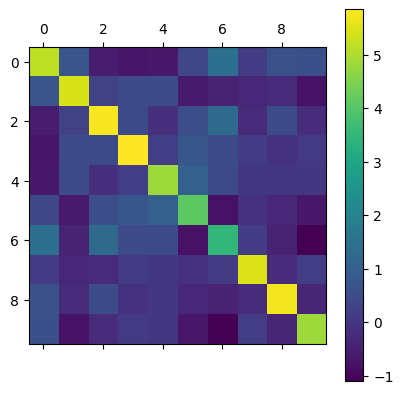

PyObject <matplotlib.colorbar.Colorbar object at 0x75216fe1a0b0>

In [85]:
J_inf = de.compute_J(opt_results_gamma.minx, d, epsilon)/opt_results_gamma.minx[end]
matshow(J_inf)
colorbar()

In [86]:
teacher_ene = compute_energy(data.round[end].x, J, θ)
student_ene = compute_energy(data.round[end].x, opt_results_gamma.minx, epsilon);

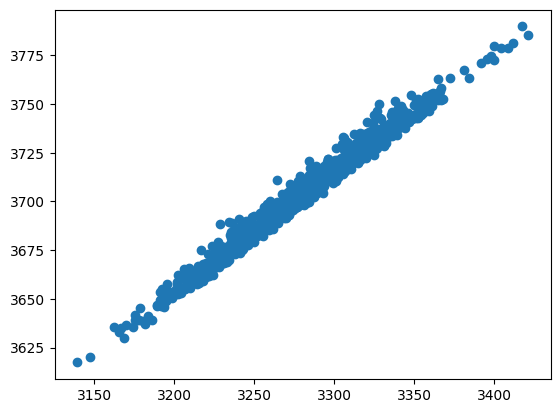

PyObject <matplotlib.collections.PathCollection object at 0x75216fd86980>

In [87]:
scatter(teacher_ene, student_ene)

In [ ]:
fig, ax = subplots(1,3,6)
ax[1].scatter(opt_results_gamma.x_start, opt_results_gamma.minx)
ax[2].scatter(opt_results.x_start, opt_results.minx)
ax[3].scatter(opt_results_gamma.minx[1:end-1], opt_results.minx)

In [ ]:
gamma_grid = [0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
ll_val = zeros(length(gamma_grid))
for i in eachindex(gamma_grid)
    r = learn_nlopt(data; initialize=length(t_sample), xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
        ftol_rel=eps_conv, prior_x=prior_x, epsilon=epsilon, γ=gamma_grid[i])
    ll_val[i] = r.minf
end

In [ ]:
plot(gamma_grid, ll_val, linestyle="dashed", marker="o")
yscale(:log)
xlabel("gamma")
ylabel("optimal log-likelihood");

In [ ]:
ll_val_gamma = [de.log_likelihood(opt_results_gamma.minx, data, γ, lambda, 0.0, 0.0, epsilon) for γ in gamma_grid]

In [ ]:
plot(gamma_grid, ll_val_gamma, linestyle="dashed", marker="o")
xlabel("gamma")
ylabel("log-likelihood")
yscale(:log)

In [ ]:
de.learn_nlopt_only_gamma(data, x0=opt_results.minx, xtol_abs=eps_conv, xtol_rel=eps_conv, ftol_abs=eps_conv,
    ftol_rel=eps_conv, lambda=lambda, prior_gamma=0.0, epsilon=epsilon) 

In [ ]:
r = de.maximize(data; initialize=0, γ=0.1, xtol_rel=eps_conv, 
    ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, maxtime=-1, maxeval=-1, lambda=lambda,
    prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=20);

In [ ]:
r.minγ

In [ ]:
plot(r.ll_iter)
yscale(:log)

In [ ]:
b=de.form_batches(250,30)

In [ ]:
unique(vcat(b...)) |> extrema

# Multithread

In [ ]:
lambda = 0.01
prior_x = 0.01
prior_gamma = 0.01
epsilon = 1e-6
eps_conv = 1e-5

In [ ]:
d_val = [3,5,7,10]

In [ ]:
Threads.@threads for i in eachindex(d_val)
    f = "logs/opt_d$(d_val[i]).txt"
    data = collect_data(zeros(d_val[i]), x_sim[1:d_val[i],:,t_sample], fill(1.0, nsamples, length(t_sample)), t_sample)
    r = iterative_maximization(data; initialize=0, gamma=0.1, xtol_rel=eps_conv, 
        ftol_rel=eps_conv, xtol_abs=eps_conv, ftol_abs=eps_conv, lambda=lambda,
        prior_x=prior_x, prior_gamma=prior_gamma, epsilon=epsilon, iterations=5, logfile=f)
end

# Optim

In [91]:
lambda = 0.01
prior_J = 0.0
prior_theta = 0.0
prior_gamma = 0.0
epsilon = 1e-6
f_tol =1.0e-9
g_tol = 1.0e-8
x_tol = 1.0e-12

1.0e-12

In [92]:
opt_results_gamma = learn_gamma_optim(data; initialize=length(t_sample), f_tol=f_tol, g_tol=g_tol, x_tol=x_tol,
    lambda=lambda, prior_J=prior_J, prior_theta=prior_theta, prior_gamma=prior_gamma, epsilon=epsilon)

Initializing parameters with covariance.


 * Status: failure

 * Candidate solution
    Final objective value:     2.209506e+01

 * Found with
    Algorithm:     Fminbox with L-BFGS

 * Convergence measures
    |x - x'|               = 4.66e-05 ≰ 1.0e-12
    |x - x'|/|x'|          = 6.62e-09 ≰ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 1.0e-09
    |g(x)|                 = 4.08e-05 ≰ 1.0e-08

 * Work counters
    Seconds run:   10  (vs limit Inf)
    Iterations:    1000
    f(x) calls:    5300
    ∇f(x) calls:   5300


In [93]:
opt_results_gamma.minimizer

111-element Vector{Float64}:
 1484.403883298839
 -375.5653366962789
  238.76474063445565
 -327.27879633278354
 -453.1535644091158
  206.71849109030785
  655.161299406836
  784.0650813918488
  181.22103194678974
  166.37050610947406
  230.55867667245744
 1992.2586456908343
  130.1484991451199
    ⋮
 1642.8945206825463
   -1.1776529138256888
    0.7804462562909925
   -0.6998566088592086
   -0.48043694025913736
   -0.7251515732346828
    1.2211336228802694
    1.8087302530014566
    0.043488948393488706
    0.5088455992604155
    0.9456590741337482
    8.002366783515805